# Aeronet: Particle Data

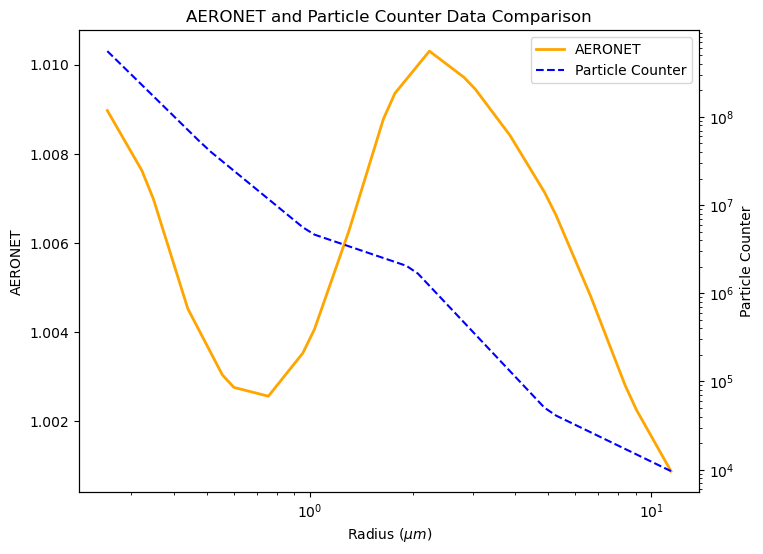

In [8]:
# integration/interpolation of Aeronet Data
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from matplotlib import pyplot as plt

# Aeronet Data Clean Up
febaero = pd.read_csv("FebAero.csv", skiprows = 6, header = 0, nrows = 3)   
min_rad = 0.255105
max_rad = 11.432287            # reads in file, cleans it up of unwanted data
keep_cols = [col for col in febaero.columns if col.replace(".", "").isdigit() and min_rad <= float(col) <= max_rad]      # reads radius bin sizes (wanted data)
febaero = febaero[keep_cols]              # replaces file variable with wanted data
#print(f"Aeronet Data: \n {marchaero}")

# linearize the data
febaero_linear = 10**febaero

# set up axis
x_aero = [float(col) for col in febaero_linear.columns]     # converts column headers to floats
y_aero = febaero_linear.mean().values                    # finds the mean of linearized data in each column
#print(marchaero_linear)


# Paricle Counter Data Clean Up
# import particle counter data
particle = pd.read_csv("ParticleCounter.csv", usecols= range(1,13), skiprows = range(1,29), nrows = 98)   # reads in file and cleans up data from launch to decent
total_particles = particle[["Count1 (dM3)", "Count2 (dM3)", "Count3 (dM3)", "Count4 (dM3)", "Count5 (dM3)", "Count6 (dM3)"]].sum
#print(particle)

particle_counts = [col for col in particle.columns if "Count" in col]  # makes column Count list
column_sums = particle[particle_counts].sum()                          # sums columns through the atmosphere to make them comparable to the aeronet
particle_size = [0.3, 0.5, 1, 2, 5, 10]

# set up axis 
x_particle = np.array(particle_size)                # creates array of radius sizes
y_particle = column_sums.values                   # creates array of data     

x_grid = np.geomspace(min_rad, max_rad, 50)         # even distributes a logarthimic grid (log linspace)

# beginning interpolation math  -- this rebins the radius sizes of each data set to match each other
# aeronet interpolation:
aero_inter = interp1d(np.log10(x_aero), np.log10(y_aero), kind = "linear", fill_value = "extrapolate")                 # kind connects the points linearly
y_aeroint = 10**aero_inter(np.log10(x_grid))                                                                           # fill value guesses the next point 
                                                                                                                       # if it's missing from the data set   
# particle counter interpolation:
particle_inter = interp1d(np.log10(x_particle), np.log10(y_particle), kind = "linear", fill_value = "extrapolate")     # interpolation math effectively logs the data
y_partint = 10**particle_inter(np.log10(x_grid))                                                                       # to make it easy, then unlogs it to fit it to the graph

# plot particles vs aeronet
plt.figure(figsize = (8,6))
line1, = plt.plot(x_grid, y_aeroint, label = "AERONET", color = "orange", lw=2)
ax1 = plt.gca()
ax2 = ax1.twinx()
line2, = ax2.plot(x_grid, y_partint, label = "Particle Counter", color = "blue", linestyle = "--")
ax1.set_ylabel("AERONET")
ax2.set_ylabel("Particle Counter")
plt.xscale("log")
plt.yscale("log")
ax1.set_xlabel("Radius ($\mu m$)")
plt.title("AERONET and Particle Counter Data Comparison")
plt.legend(handles = (line1, line2))
#plt.savefig("AERONET_Plot.png", dpi = 300)